# Interactive Klein bottle

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import ipywidgets as widgets
from ipywidgets import Layout

import numpy as np
import matplotlib.pyplot as plt
%matplotlib ipympl

#Colour
colour = 'blue'

#Rounding
dp=2

#Parameters
plt.rcParams['text.usetex'] = True

p = widgets.FloatText(value=1,min=0,max=5,step=.1,description='p')
a = widgets.FloatText(value=3.4,min=0,max=5,step=.1,description='a')
b = widgets.FloatText(value=4,min=0,max=5,step=.1,description='b')
theta = widgets.FloatText(value=.7,min=0,max=np.pi/2,step=.01,description='θ')
phi = widgets.FloatText(value=.45,min=0,max=np.pi/2,step=.01,description='ϕ')
w = widgets.FloatText(value=8.6,min=0,max=20,step=.1,description='w')

def g(p,a,b,theta,phi,w):
    plt.clf()
    plt.close()
    
    h = (a+b+(a-b)*np.cos(theta))/np.sin(theta)
    d = np.sqrt((w/2)*((w/2)-p)/2)
    c = (h*np.sin(phi)+p*np.cos(phi)-(w/2))/(1-np.cos(phi))
    
    P = np.array([0,a*(1+np.cos(theta)),h-a*np.sin(theta)])
    Q = np.array([0,b*(1-np.cos(theta)),b*np.sin(theta)])
    PQ = Q-P
    magPQ = np.sqrt(PQ[1]**2+PQ[2]**2)
    PQhat = PQ/magPQ
    
    X = np.array([0,(w/2)*np.cos(phi),(w/2)*np.sin(phi)])
    Y = np.array([0,p+c-c*np.cos(phi),h-c*np.sin(phi)])
    
    #Arc lengths and step sizes
    AL = np.array([2*d, (w/2)*np.sin(phi), h-c*np.sin(phi)-(w/2)*np.sin(phi), c*np.sin(phi), a*(np.pi+theta), magPQ, b*theta])
    TotalAL = np.sum(AL)
    Proportions = AL/TotalAL
    TotalSteps = 1000
    Steps = np.round(TotalSteps*Proportions)
    
    #Figure
    fig = plt.figure(figsize = (7,8), label = ' ')
    fig.tight_layout()
    ax = plt.axes(projection='3d')
    
    #Main bottle 
    #Base (Bottle 0)
    #Not canal surface parametrisation! But join has dotr=0 so values match.
    u = np.linspace(0,np.pi,int(Steps[0]))
    v = np.linspace(0,2*np.pi,100)
    u, v = np.meshgrid(u, v)
    
    x = (((w/2)+p)/2-(((w/2)-p)/2)*np.cos(u))*np.cos(v)
    y = (((w/2)+p)/2-(((w/2)-p)/2)*np.cos(u))*np.sin(v)
    z = -d*np.sin(u) + d
    
    ax.plot_surface(x, y, z, color = colour, edgecolor = 'black', linewidth = .1, alpha = .25)
    
    #Rest of the sections have canal surface parametrisation 
    
    #Bottle 1
    u = np.linspace(d,d + (w/2)*np.sin(phi), int(Steps[1]))
    v = np.linspace(0,2*np.pi,100)
    u, v = np.meshgrid(u, v)
    
    #Diretrix
    gamma = (0,0,u)
    
    #ON Frame
    T = (0,0,1)
    N = (1,0,0)
    B = (0,1,0)
    
    #Radius function
    r = np.sqrt((w/2)**2-(u-d)**2)
    rdot = -(u-d)/np.sqrt((w/2)**2-(u-d)**2)
    
    x = gamma[0] - r*rdot*T[0] + r*np.sqrt(1-(rdot)**2)*(N[0]*np.cos(v)+B[0]*np.sin(v)) 
    y = gamma[1] - r*rdot*T[1] + r*np.sqrt(1-(rdot)**2)*(N[1]*np.cos(v)+B[1]*np.sin(v)) 
    z = gamma[2] - r*rdot*T[2] + r*np.sqrt(1-(rdot)**2)*(N[2]*np.cos(v)+B[2]*np.sin(v)) 
    
    ax.plot_surface(x, y, z, color = colour, edgecolor = 'black', linewidth = .1, alpha = .25)
    
    
    #Bottle 2
    u = np.linspace(d + (w/2)*np.sin(phi), d + h-c*np.sin(phi), int(Steps[2]))
    v = np.linspace(0,2*np.pi,100)
    u, v = np.meshgrid(u, v)
    
    #Diretrix
    gamma = (0,0,u)
    
    #ON Frame
    T = (0,0,1)
    N = (1,0,0)
    B = (0,1,0)
    
    #Radius function
    r = (w/2)/np.cos(phi)-(u-d)*np.tan(phi)
    rdot = -np.tan(phi)
    
    x = gamma[0] - r*rdot*T[0] + r*np.sqrt(1-(rdot)**2)*(N[0]*np.cos(v)+B[0]*np.sin(v)) 
    y = gamma[1] - r*rdot*T[1] + r*np.sqrt(1-(rdot)**2)*(N[1]*np.cos(v)+B[1]*np.sin(v)) 
    z = gamma[2] - r*rdot*T[2] + r*np.sqrt(1-(rdot)**2)*(N[2]*np.cos(v)+B[2]*np.sin(v)) 
    
    ax.plot_surface(x, y, z, color = colour, edgecolor = 'black', linewidth = .1, alpha = .25)
    
    #Bottle 3
    u = np.linspace(d + h-c*np.sin(phi), d + h, int(Steps[3]))
    v = np.linspace(0,2*np.pi,100)
    u, v = np.meshgrid(u, v)
    
    #Diretrix
    gamma = (0,0,u)
    
    #ON Frame
    T = (0,0,1)
    N = (1,0,0)
    B = (0,1,0)
    
    #Radius function
    r = p+c-np.sqrt(c**2-(u-h-d)**2)
    rdot = (u-d-h)/np.sqrt(c**2-(u-h-d)**2)
    
    x = gamma[0] - r*rdot*T[0] + r*np.sqrt(1-(rdot)**2)*(N[0]*np.cos(v)+B[0]*np.sin(v)) 
    y = gamma[1] - r*rdot*T[1] + r*np.sqrt(1-(rdot)**2)*(N[1]*np.cos(v)+B[1]*np.sin(v)) 
    z = gamma[2] - r*rdot*T[2] + r*np.sqrt(1-(rdot)**2)*(N[2]*np.cos(v)+B[2]*np.sin(v)) 
    
    ax.plot_surface(x, y, z, color = colour, edgecolor = 'black', linewidth = .1, alpha = .25)
    
    #Handle
    #Handle 1
    u = np.linspace(0, a*(np.pi+theta), int(Steps[4]))
    v = np.linspace(0,2*np.pi,100)
    u, v = np.meshgrid(u, v)
    
    #Diretrix
    gamma = (0,a*(1+np.cos(np.pi-u/a)),d + h+a*np.sin(np.pi-u/a))
    
    #ON Frame
    T = (0,-np.sin(np.pi-u/a),np.cos(np.pi-u/a))
    N = (0,-np.cos(np.pi-u/a),-np.sin(np.pi-u/a))
    B = (1,0,0)
    
    #Radius function
    r = p
    rdot = 0
    
    x = gamma[0] - r*rdot*T[0] + r*np.sqrt(1-(rdot)**2)*(N[0]*np.cos(v)+B[0]*np.sin(v)) 
    y = gamma[1] - r*rdot*T[1] + r*np.sqrt(1-(rdot)**2)*(N[1]*np.cos(v)+B[1]*np.sin(v)) 
    z = gamma[2] - r*rdot*T[2] + r*np.sqrt(1-(rdot)**2)*(N[2]*np.cos(v)+B[2]*np.sin(v)) 
    
    ax.plot_surface(x, y, z, color = colour, edgecolor = 'black', linewidth = .1, alpha = .25)
    
    #Handle 2
    u = np.linspace(0, magPQ, int(Steps[5]))
    v = np.linspace(0,2*np.pi,50)
    u, v = np.meshgrid(u, v)
    
    #Diretrix
    gamma = (0, (u/magPQ)*Q[1] + (1-u/magPQ)*P[1], d + (u/magPQ)*Q[2] + (1-u/magPQ)*P[2])
    
    #ON Frame
    T = (0,PQhat[1],PQhat[2])
    N = (0,PQhat[2],-PQhat[1])
    B = (1,0,0)
    
    #Radius function
    r = p
    rdot = 0
    
    x = gamma[0] - r*rdot*T[0] + r*np.sqrt(1-(rdot)**2)*(N[0]*np.cos(v)+B[0]*np.sin(v)) 
    y = gamma[1] - r*rdot*T[1] + r*np.sqrt(1-(rdot)**2)*(N[1]*np.cos(v)+B[1]*np.sin(v)) 
    z = gamma[2] - r*rdot*T[2] + r*np.sqrt(1-(rdot)**2)*(N[2]*np.cos(v)+B[2]*np.sin(v)) 
    
    ax.plot_surface(x, y, z, color = colour, edgecolor = 'black', linewidth = .1, alpha = .25)
    
    #Handle 3
    u = np.linspace(0, b*theta, int(Steps[6]))
    v = np.linspace(0,2*np.pi,100)
    u, v = np.meshgrid(u, v)
    
    #Diretrix
    gamma = (0,b+b*np.cos(np.pi-theta+u/b), d + b*np.sin(np.pi-theta+u/b))
    
    #ON Frame
    T = (0,-np.sin(np.pi-theta+u/b),np.cos(np.pi-theta+u/b))
    N = (0,-np.cos(np.pi-theta+u/b),-np.sin(np.pi-theta+u/b))
    B = (1,0,0)
    
    #Radius function
    r = p
    rdot = 0
    
    x = gamma[0] - r*rdot*T[0] + r*np.sqrt(1-(rdot)**2)*(N[0]*np.cos(v)+B[0]*np.sin(v)) 
    y = gamma[1] - r*rdot*T[1] + r*np.sqrt(1-(rdot)**2)*(N[1]*np.cos(v)+B[1]*np.sin(v)) 
    z = gamma[2] - r*rdot*T[2] + r*np.sqrt(1-(rdot)**2)*(N[2]*np.cos(v)+B[2]*np.sin(v)) 
    
    ax.plot_surface(x, y, z, color = colour, edgecolor = 'black', linewidth = .1, alpha = .25)
    
    #Axis labels
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    
    ax.set_aspect('equal')
    
    ax.view_init(elev=0, azim=0, roll=0)
    
    plt.show()

output =  widgets.interactive_output(g, {'p': p, 'a': a, 'b': b, 'theta': theta, 'phi': phi, 'w': w})

parameters = widgets.VBox([widgets.HTML(value="Bottle control points:"), p, a, b, theta, phi, w],layout=Layout())

widgets.HBox([parameters,output], layout = Layout(display='flex', align_items='center'))

# Interactive Klein bottle directrix

The following interactive widget is to help determine directrix shape. 

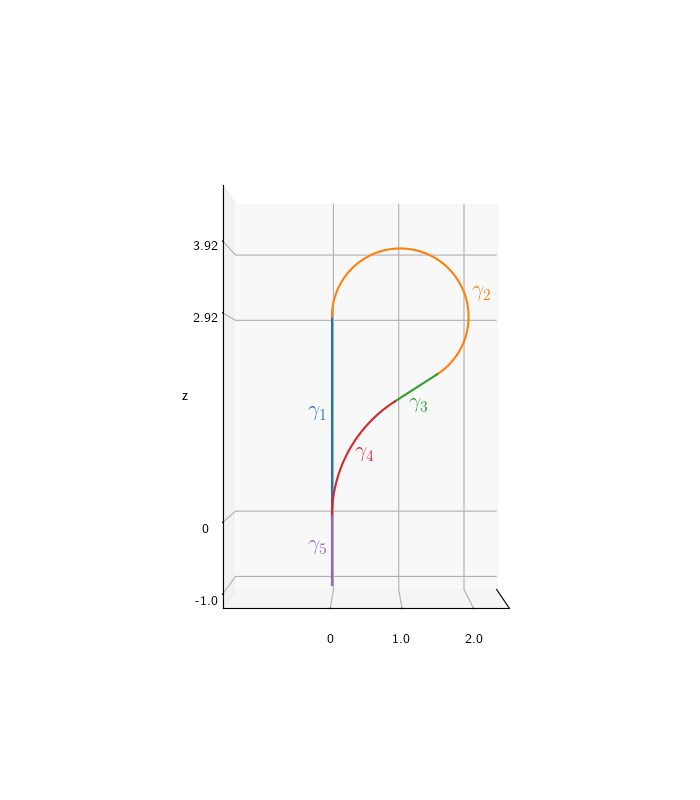

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import ipywidgets as widgets
from ipywidgets import Layout

import numpy as np
import matplotlib.pyplot as plt
%matplotlib ipympl

plt.rcParams['text.usetex'] = True

d = widgets.FloatSlider(value=-1,min=-5,max=0,step=.1,description='d')
a = widgets.FloatSlider(value=1,min=0,max=5,step=.1,description='a')
b = widgets.FloatSlider(value=2,min=0,max=5,step=.1,description='b')
theta = widgets.FloatSlider(value=1,min=0,max=np.pi/2,step=.1,description='θ')

def f(d,a,b,theta):
    plt.clf()
    plt.close()
    
    h = (a+b+(a-b)*np.cos(theta))/np.sin(theta)
    
    P = np.array([0,a*(1+np.cos(theta)),h-a*np.sin(theta)])    
    Q = np.array([0,b*(1-np.cos(theta)),b*np.sin(theta)])
    PQ = Q-P
    magPQ = np.sqrt(PQ[1]**2+PQ[2]**2)
    
    fig = plt.figure(figsize = (7,8), label = ' ')
    ax = plt.axes(projection='3d')
    
    #Straight segment 1
    u = np.linspace(0, np.pi, 2)
    
    t = np.linspace(0, h-d, 2)
    
    x = 0
    y = 0
    z = d+t
    
    ax.plot(x, y, z, color='tab:blue')
    ax.text(0, -.35*a ,h/2 ,r'$\gamma_1$', color='tab:blue', fontsize=16)
    
    #Circular segment 1
    
    t = np.linspace(0, a*(np.pi+theta), 100)
    
    x = 0
    y = a*(1+np.cos(np.pi-t/a))
    z = h+a*np.sin(np.pi-t/a)
    
    ax.plot(x, y, z, color='tab:orange')
    ax.text(0, 2.05*a ,1.1*h ,r'$\gamma_2$', color='tab:orange', fontsize=16)
    
    #Straight segment 2
    
    t = np.linspace(0, magPQ, 2)
    
    x = (t/magPQ)*Q[0] + (1-t/magPQ)*P[0]
    y = (t/magPQ)*Q[1] + (1-t/magPQ)*P[1]
    z = (t/magPQ)*Q[2] + (1-t/magPQ)*P[2]
    
    ax.plot(x, y, z, color='tab:green')
    ax.text(0, (P[1]+Q[1])/2-.1*a ,(P[2]+Q[2])/2-.3*a ,r'$\gamma_3$', color='tab:green', fontsize=16)
    
    #Circular segment 2
    
    t = np.linspace(0, b*theta, 100)
    
    x = 0
    y = b+b*np.cos(np.pi-theta+t/b)
    z = b*np.sin(np.pi-theta+t/b)
    
    ax.plot(x, y, z, color='tab:red')
    ax.text(0, b+b*np.cos(np.pi-theta/2)+.1*a, b*np.sin(np.pi-theta/2)-.1*a, r'$\gamma_4$', color='tab:red', fontsize=16)
    
    #Straight segment 3
    
    t = np.linspace(0, -d, 2)
    
    x = 0
    y = 0
    z = -t
    
    ax.plot(x, y, z, color='tab:purple')
    ax.text(0, -.35*a, d/2, r'$\gamma_5$', color='tab:purple', fontsize=16)
    
    #Annotations
    #ax.scatter(P[0],P[1],P[2],color='k')
    #ax.text(P[0],P[1],P[2]-.5*a, "P")
    
    #ax.scatter(Q[0],Q[1],Q[2],color='k')
    #ax.text(Q[0],Q[1],Q[2]-.5*a, "Q")
    
    # Axis labels
    ax.set_xlabel(' ')
    ax.set_ylabel(' ')
    ax.set_zlabel('z')
    
    ax.set(xlim=(-2,2), ylim=(-1.5*a,2.5*a), zlim=(1.2*d,1.2*(h+a)))
    
    #Ticks
    ax.set_xticks([])
    dp=2
    
    if b<=a:
        ax.set_yticks([0,b,a], labels=["0", str(float(np.round(b,dp))), str(float(np.round(a,dp)))])
    else:
        ax.set_yticks([0,a,b], labels=["0", str(float(np.round(a,dp))), str(float(np.round(b,dp)))])
    
    ax.set_zticks([d, 0,h,h+a], labels=[str(d), "0", str(float(np.round(h,dp))), str(float(np.round(h+a,dp)))])
    
    ax.set_aspect('equal')
    
    ax.view_init(elev=0, azim=0, roll=0)

output =  widgets.interactive_output(f, {'d': d, 'a': a, 'b': b, 'theta': theta})

In [3]:

parameters = widgets.VBox([widgets.HTML(value="Bottle control points:"), d, a, b, theta],layout=Layout())
display(parameters)
